In [1]:
file = "001_yield"

In [2]:
import polars as pl

df = pl.read_excel("combined.xlsx")

In [3]:
df

arene,alkene,PG,backbone,pyridone,alpha1,beta1,all1,alpha2,beta2,all2,alpha_av,beta_av,all_av,alpha_dev,beta_dev,all_dev
i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0,0,0,0,3.659641,49.211079,52.870719,4.569624,53.565635,58.135259,4.114632,51.388357,55.502989,-0.909983,-4.354556,-5.264539
0,0,0,0,1,3.12128,64.922922,68.044201,3.705099,62.760926,66.466025,3.413189,63.841924,67.255113,-0.583819,2.161996,1.578176
0,0,0,0,2,2.364572,59.87745,62.242023,2.590455,58.292872,60.883327,2.477514,59.085161,61.562675,-0.225882,1.584578,1.358696
0,0,0,0,3,2.446972,52.129263,54.576235,2.916464,53.990178,56.906642,2.681718,53.059721,55.741439,-0.469492,-1.860915,-2.330407
0,0,0,0,4,2.803536,48.334072,51.137609,3.830003,59.501541,63.331543,3.31677,53.917807,57.234576,-1.026466,-11.167468,-12.193935
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0,20,8,3.437961,20.51143,23.949391,2.866987,17.944757,20.811744,3.152474,19.228094,22.380568,0.570974,2.566673,3.137647
0,0,0,20,9,4.480165,26.729398,31.209563,3.391717,22.462407,25.854125,3.935941,24.595903,28.531844,1.088448,4.266991,5.355439
0,0,0,20,10,3.692312,23.079329,26.771641,2.970595,19.041197,22.011791,3.331453,21.060263,24.391716,0.721717,4.038132,4.75985


# 0. Beta product

In [4]:
df_pivot = df.pivot("pyridone", index="backbone", values="beta_av")

In [5]:
df_pivot

backbone,0,1,2,3,4,5,6,7,8,9,10,11,12
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,51.388357,63.841924,59.085161,53.059721,53.917807,56.153319,50.969403,51.655351,48.798774,50.342873,47.894528,47.205211,46.286168
1,51.539999,64.041771,56.625391,51.200555,54.038835,54.044189,49.023217,49.860733,47.966785,49.085003,46.084394,44.96226,46.020327
2,47.832328,63.155406,58.624277,50.955722,50.321093,53.047256,50.474366,47.727759,45.182829,45.24369,42.843225,42.356297,45.612098
3,47.845209,70.080418,62.904552,55.457276,50.60889,55.81095,51.602399,47.800828,39.74552,42.31506,41.484904,38.07556,46.114252
4,43.960253,65.421028,60.001959,56.67244,48.821888,57.136955,52.589578,46.297638,42.388401,42.981152,42.519636,39.133657,49.74711
5,53.653941,65.839352,59.588924,59.621349,55.933165,54.126938,53.196183,52.763604,55.189066,54.225982,54.513381,53.361149,48.959898
19,49.506825,64.736624,61.648018,54.383662,54.143679,55.091201,51.117783,46.249826,32.852357,39.645974,40.710818,33.010984,41.066778
20,17.00806,19.97189,29.540207,49.963688,27.611356,24.408821,17.804581,17.219599,19.228094,24.595903,21.060263,19.203989,23.601443


In [6]:
df_pivot_ = df_pivot.drop("backbone")
data = df_pivot_.to_numpy()

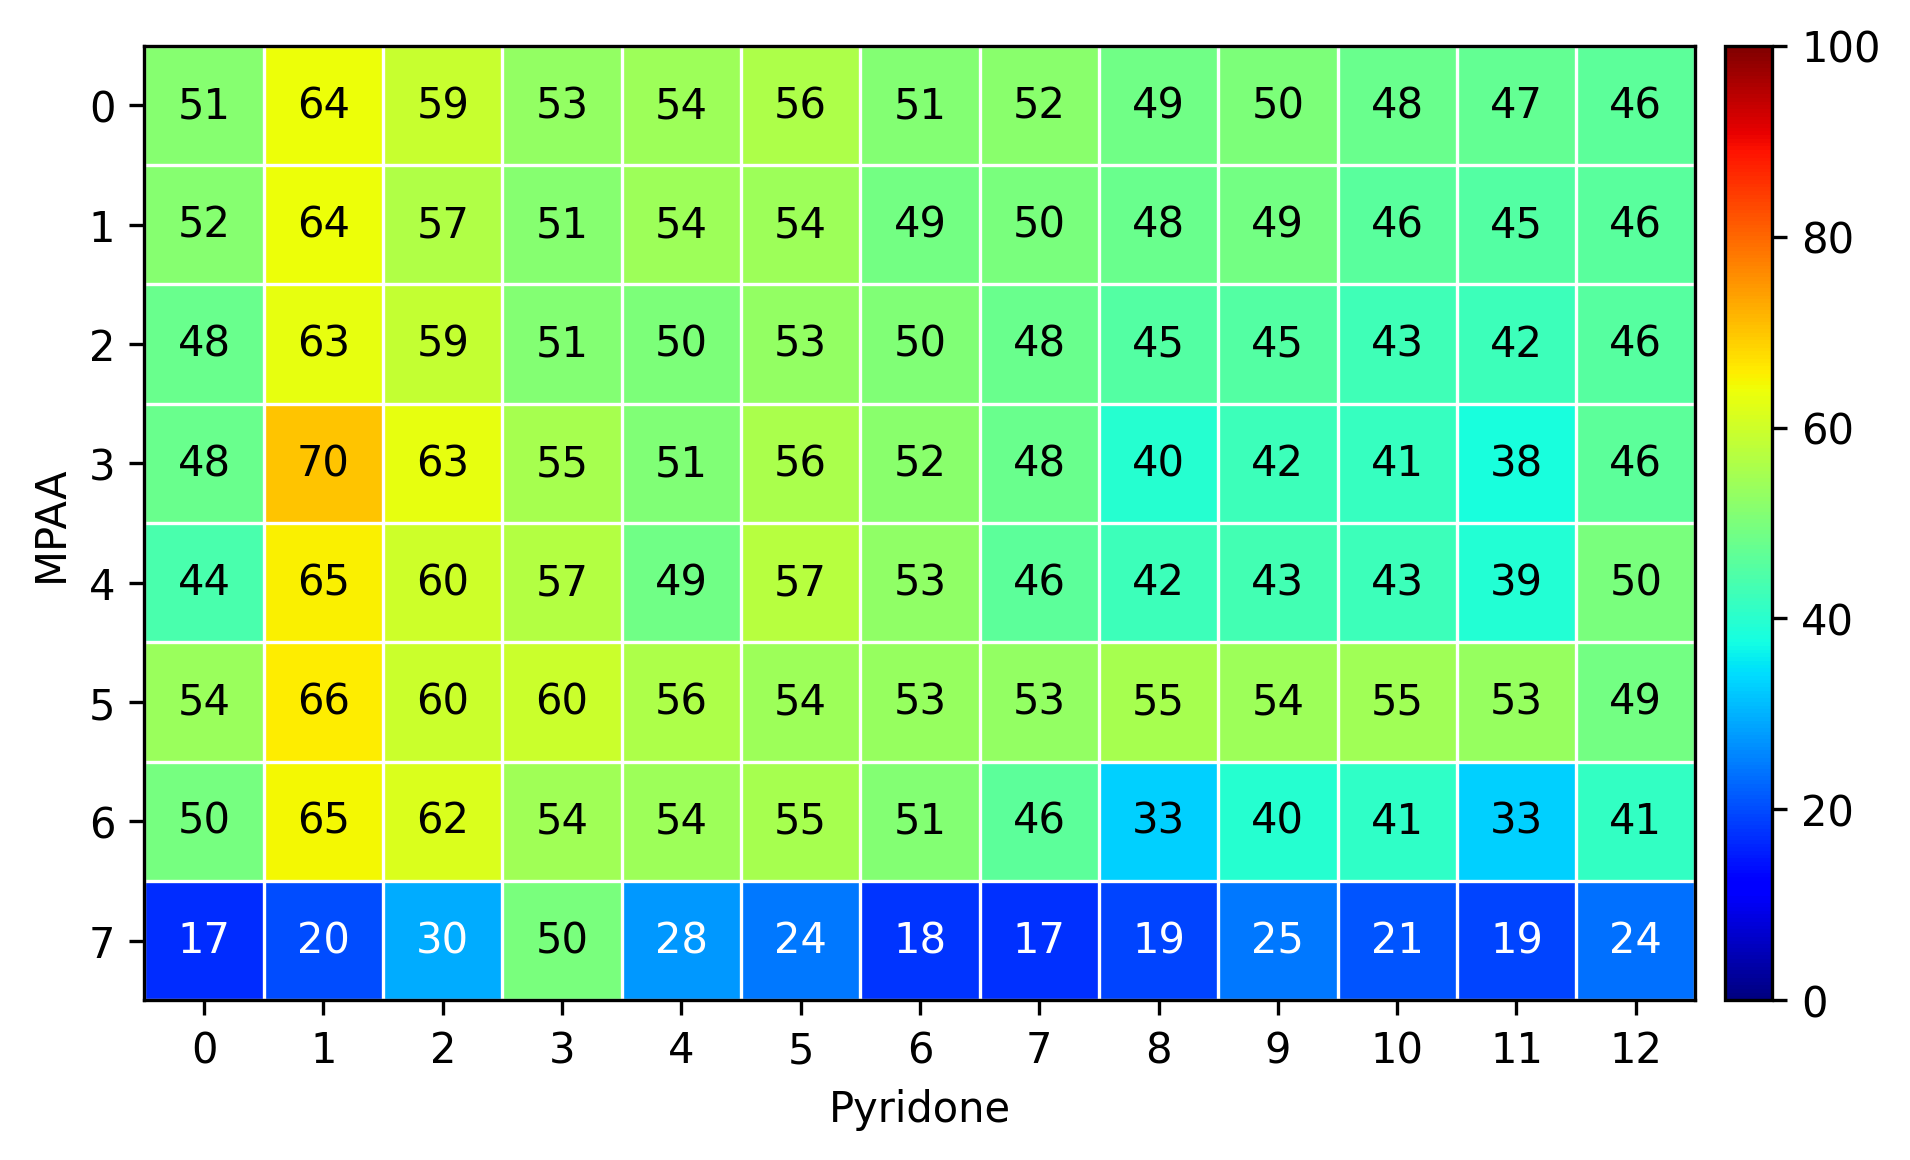

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

im = ax.imshow(data, vmin=0, vmax=100, cmap="jet")

ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xlabel("Pyridone")
ax.set_ylabel("MPAA")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels(df_pivot_.columns)
ax.set_yticklabels(np.arange(data.shape[0]))

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = int(round(data[i, j]))
        color = "white" if val <= 30 else "black"
        ax.text(
            j, i,
            val,
            ha="center",
            va="center",
            color=color
        )

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file}_imshow_beta.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

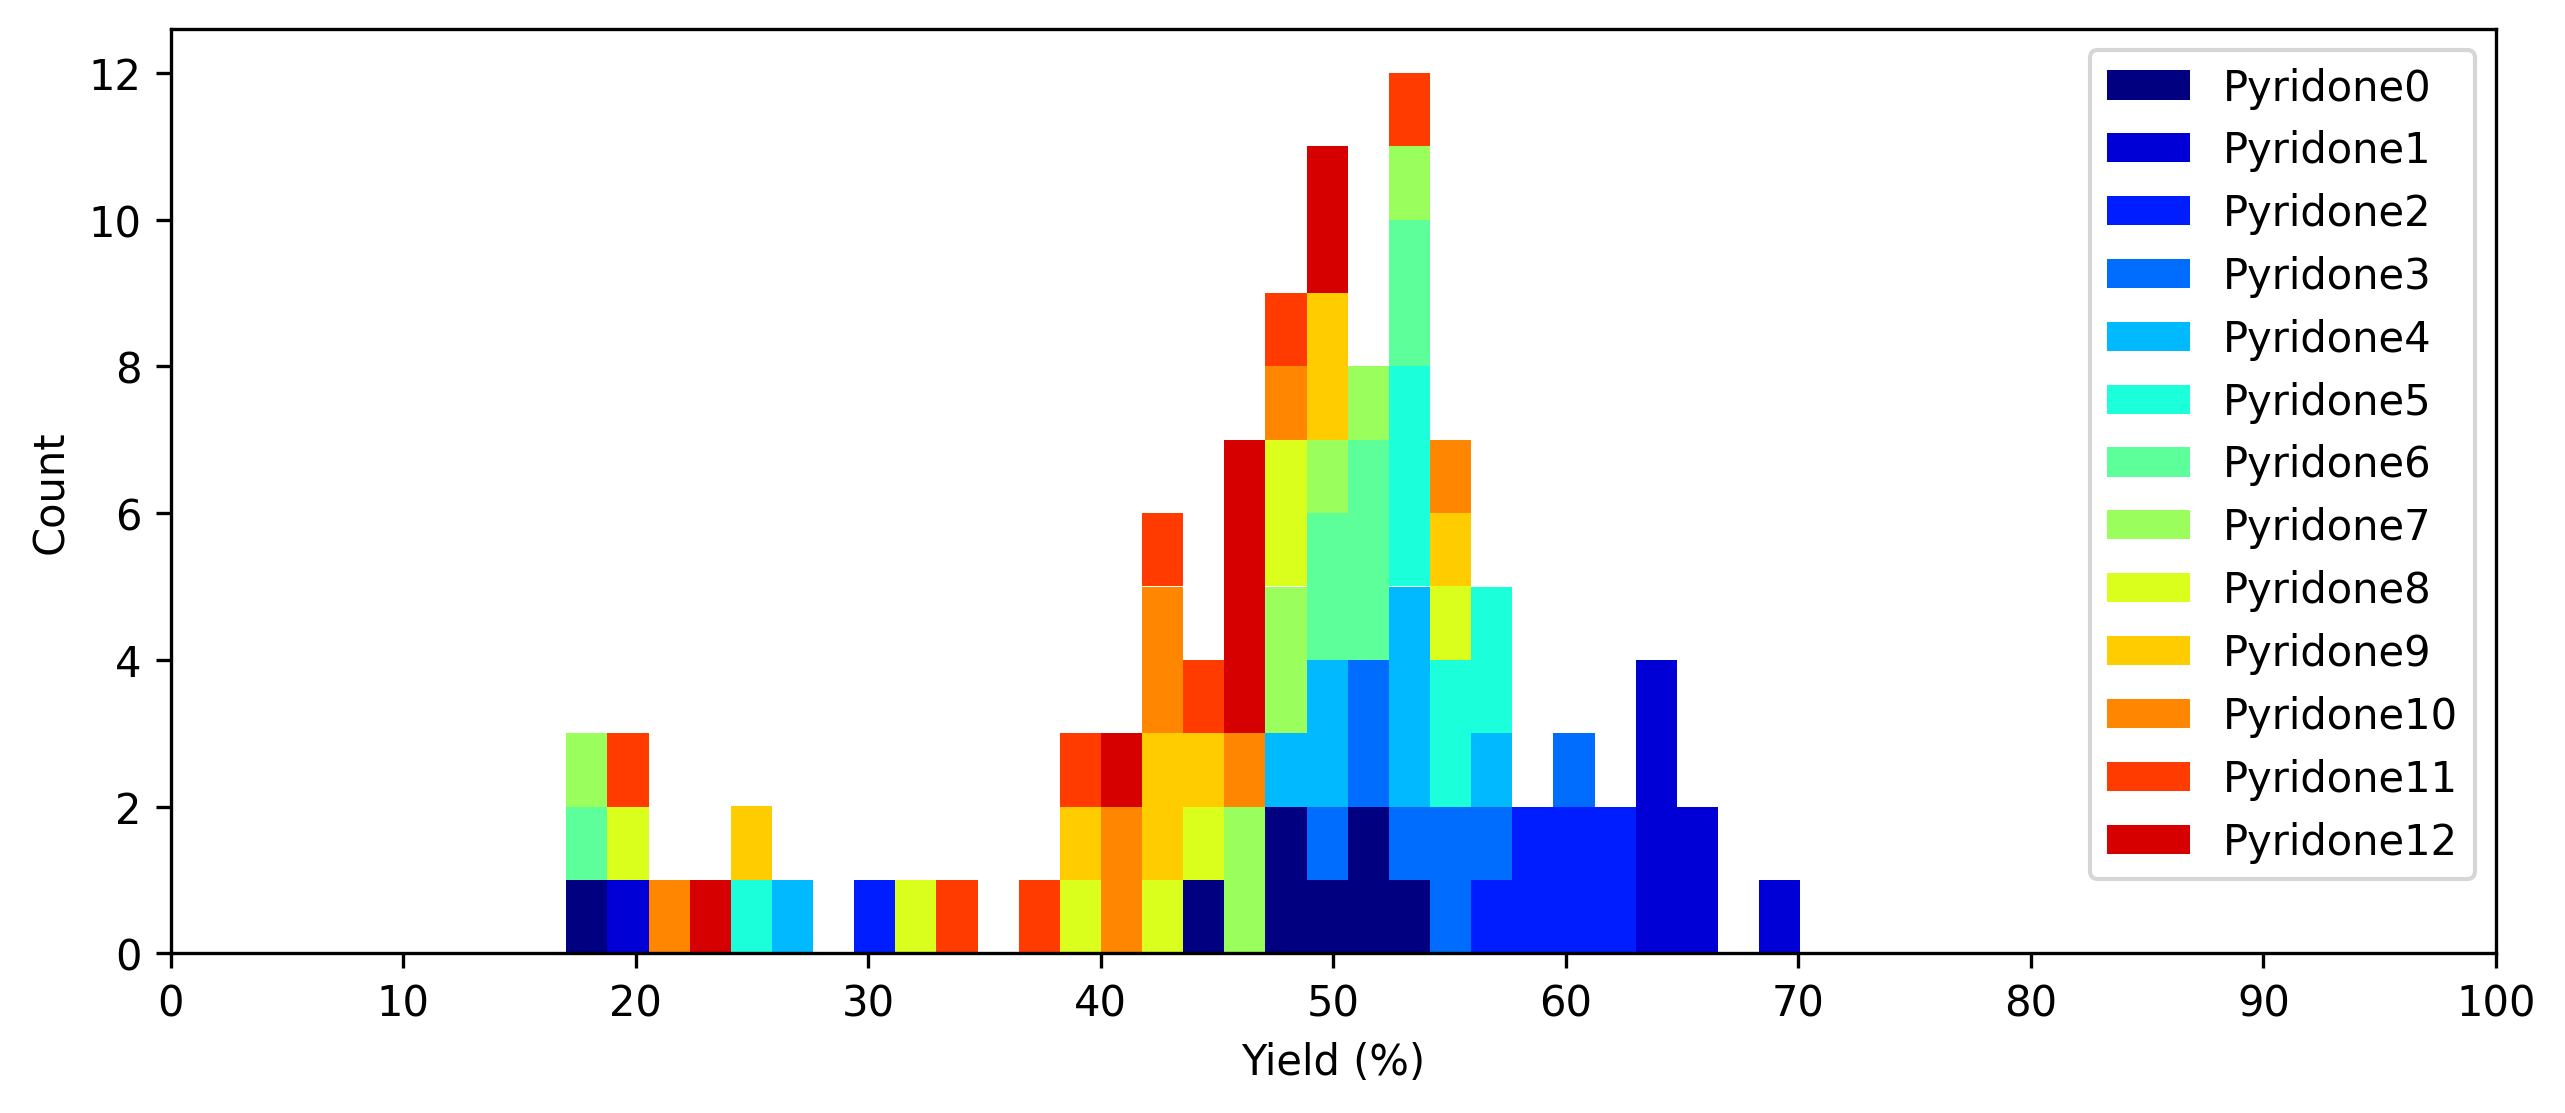

In [8]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

color = [plt.cm.jet(i / df_pivot_.width) for i in range(df_pivot_.width)]
label = [f"Pyridone{i}"for i in range(df_pivot_.width)]
ax.hist(
    df_pivot_,
    bins=30,
    stacked=True,
    color=color,
    label=label
)

ax.set_xlabel("Yield (%)")
ax.set_ylabel("Count")
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xlim(0, 100)

plt.legend()
plt.savefig(
    f"{file}_hist_pyridone.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [9]:
df_pivot_ = df_pivot_.transpose()

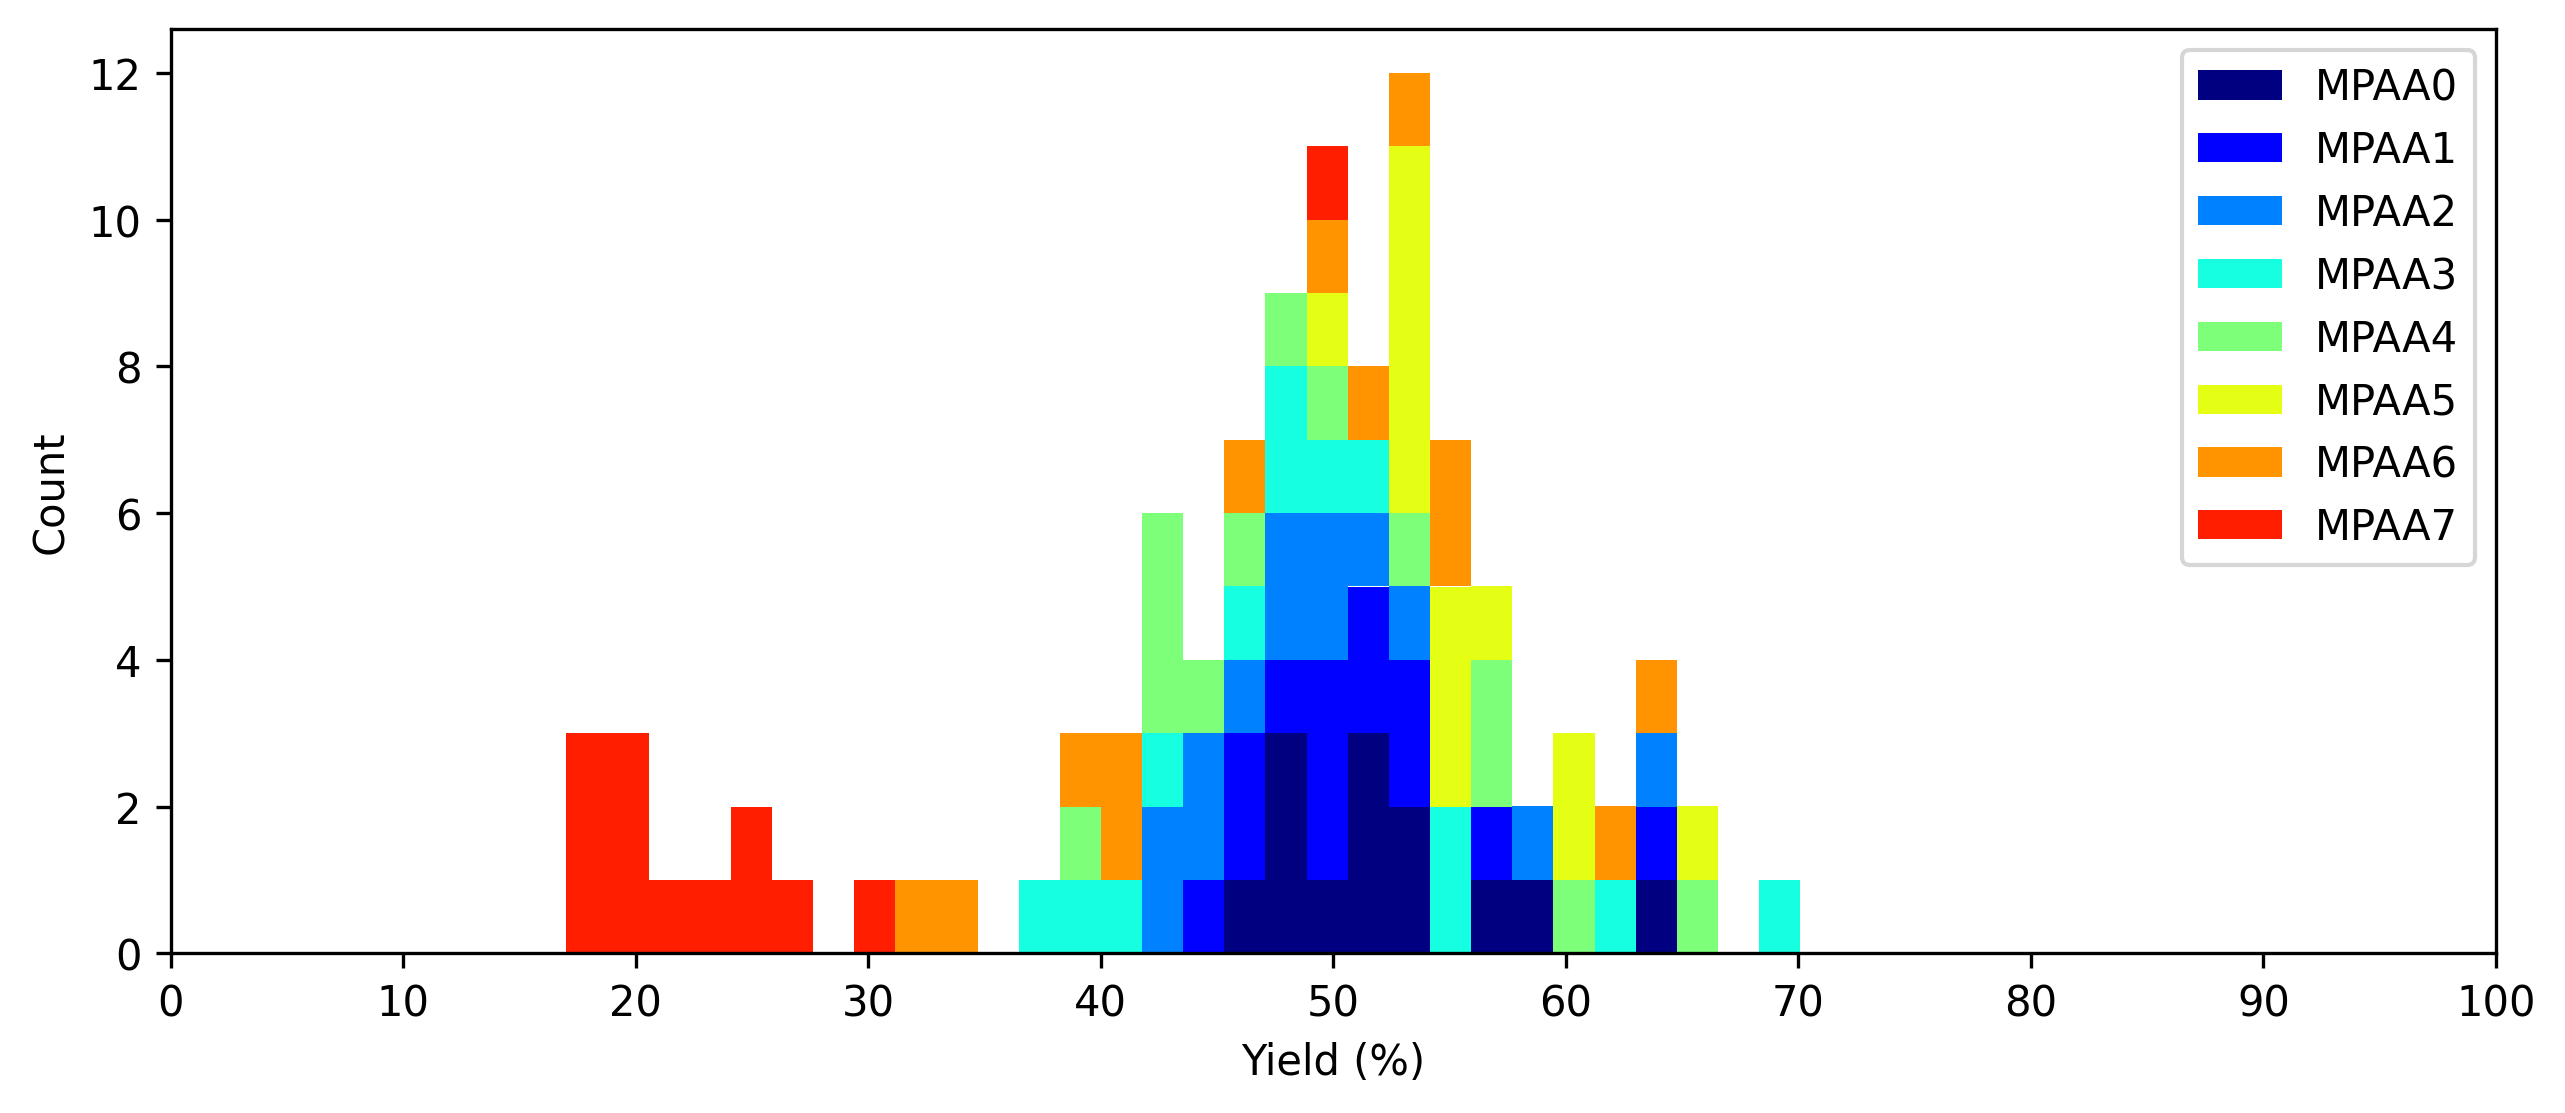

In [10]:
fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

color = [plt.cm.jet(i / df_pivot_.width) for i in range(df_pivot_.width)]
label = [f"MPAA{i}"for i in range(df_pivot_.width)]
ax.hist(
    df_pivot_,
    bins=30,
    stacked=True,
    color=color,
    label=label
)

ax.set_xlabel("Yield (%)")
ax.set_ylabel("Count")
ax.set_xticks(np.arange(0, 101, 10))
ax.set_xlim(0, 100)

plt.legend()
plt.savefig(
    f"{file}_hist_MPAA.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

# 1. Alpha product

In [11]:
df_pivot = df.pivot("pyridone", index="backbone", values="alpha_av")

In [12]:
df_pivot

backbone,0,1,2,3,4,5,6,7,8,9,10,11,12
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,4.114632,3.413189,2.477514,2.681718,3.31677,3.509626,3.872826,4.148197,4.490873,4.221548,4.677466,4.603509,3.668893
1,3.998281,3.24624,2.397874,2.591737,3.3058,3.315256,3.692958,3.887154,4.273157,3.984192,4.40103,4.325064,3.686025
2,3.428027,2.529921,2.918899,2.523317,3.283226,3.00932,3.79358,4.031006,4.183477,4.132939,4.142815,4.237517,3.068083
3,3.636433,2.968364,2.959446,2.792901,3.146997,3.439074,3.985706,4.126354,4.610745,5.04212,5.25849,5.136181,3.583822
4,3.323485,2.619338,2.871521,2.884278,2.98124,3.384506,4.122431,3.943312,4.885723,4.924919,5.362667,5.210751,3.742613
5,1.291055,1.656664,1.763143,2.092915,1.452466,1.319463,1.170237,1.224673,0.975729,0.998492,0.917776,1.003081,1.175172
19,3.860559,2.840362,2.701196,2.636505,3.225842,3.498378,4.158637,4.030064,5.002143,5.693939,6.407056,6.171228,3.338815
20,1.644606,1.053729,1.75211,3.103879,2.266289,2.521463,1.922745,2.001225,3.152474,3.935941,3.331453,3.490995,2.762772


In [13]:
df_pivot_ = df_pivot.drop("backbone")
data = df_pivot_.to_numpy()

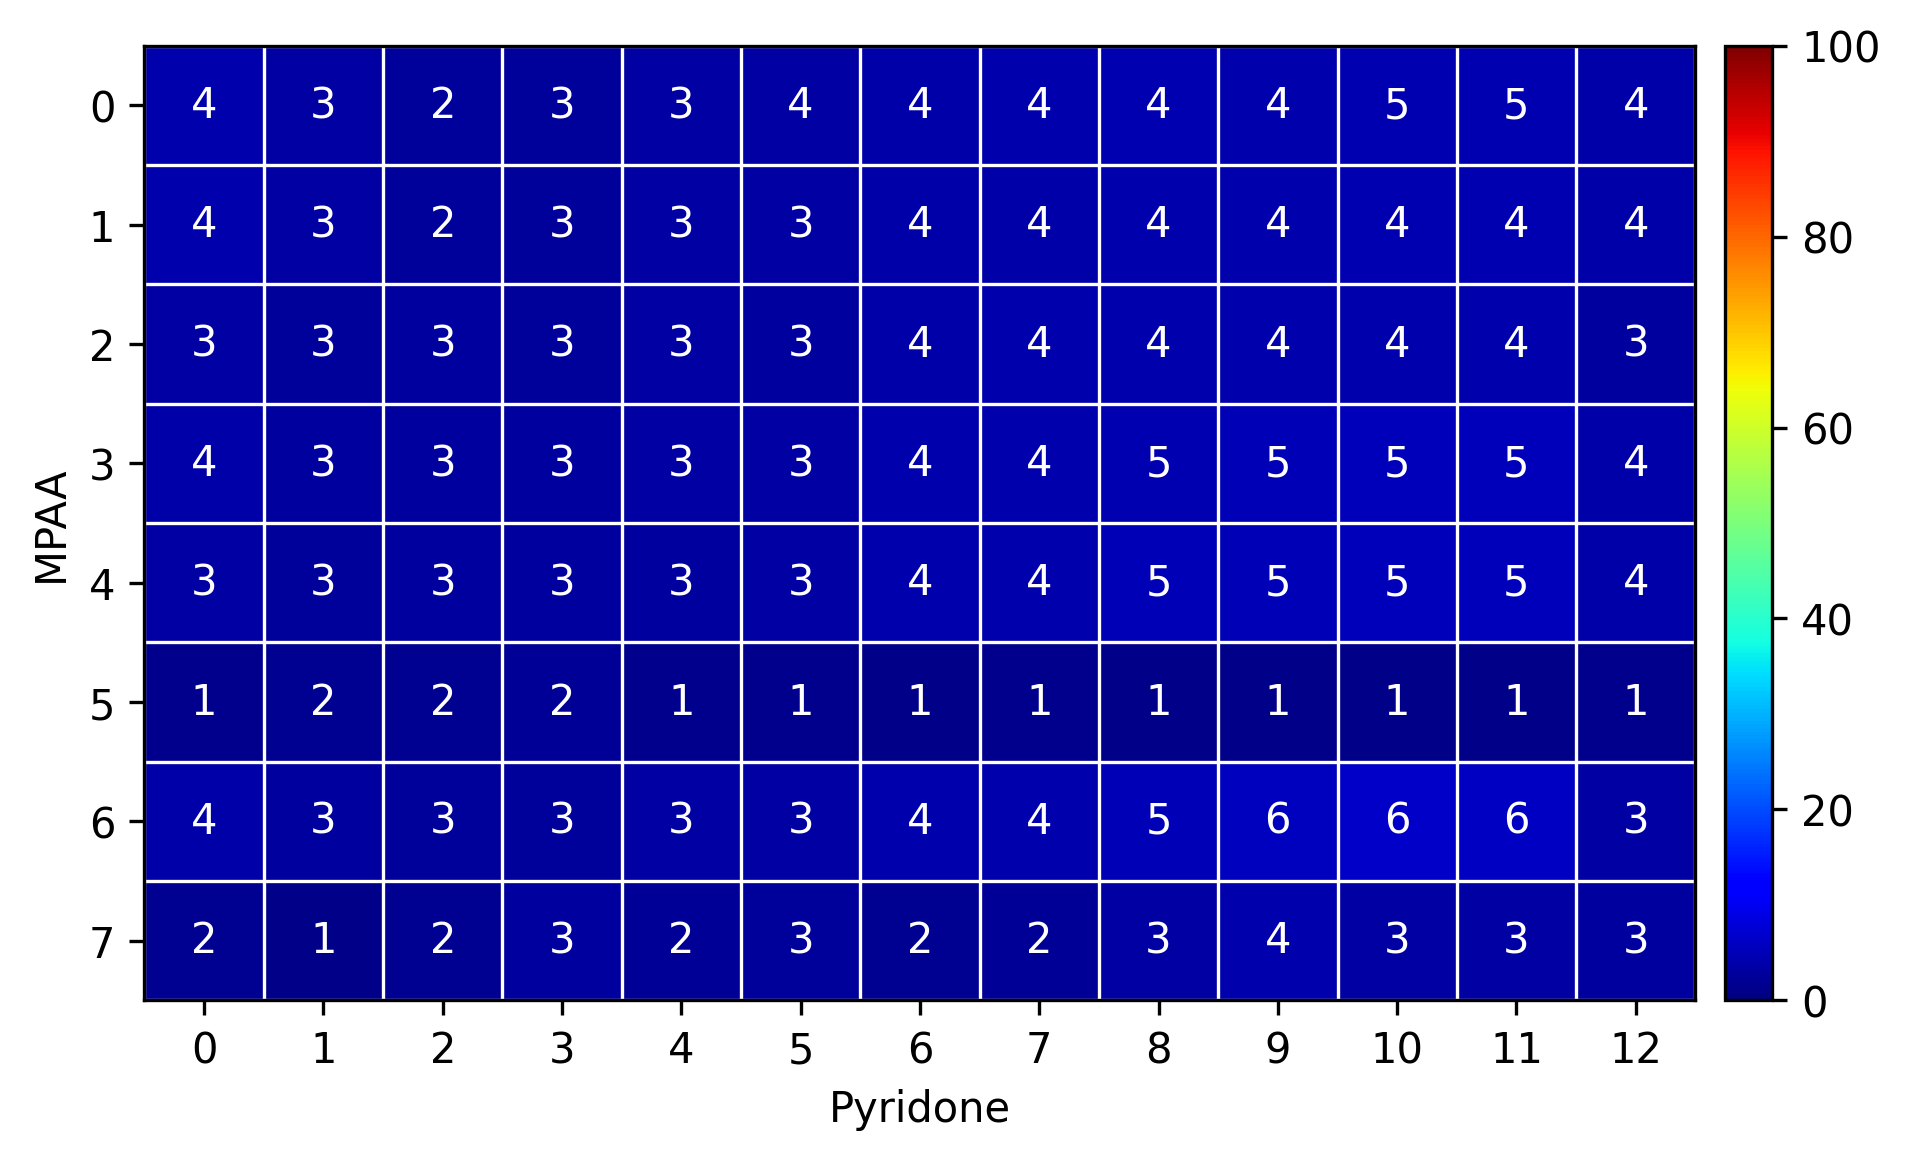

In [14]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

im = ax.imshow(data, vmin=0, vmax=100, cmap="jet")

ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xlabel("Pyridone")
ax.set_ylabel("MPAA")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels(df_pivot_.columns)
ax.set_yticklabels(np.arange(data.shape[0]))

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = int(round(data[i, j]))
        color = "white" if val <= 30 else "black"
        ax.text(
            j, i,
            val,
            ha="center",
            va="center",
            color=color
        )

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file}_imshow_alpha.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

# 2. Alpha/beta selectivity

In [15]:
df_pivot = (
    df
    .with_columns(pl.col("alpha_av").truediv("beta_av").alias("selectivity"))
    .pivot("pyridone", index="backbone", values="selectivity")
)

In [16]:
df_pivot

backbone,0,1,2,3,4,5,6,7,8,9,10,11,12
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.080069,0.053463,0.041931,0.050541,0.061515,0.062501,0.075983,0.080305,0.092028,0.083856,0.097662,0.097521,0.079265
1,0.077576,0.050689,0.042346,0.050619,0.061175,0.061343,0.075331,0.07796,0.089086,0.081169,0.095499,0.096193,0.080096
2,0.071668,0.040059,0.04979,0.04952,0.065246,0.056729,0.075159,0.084458,0.09259,0.091348,0.096697,0.100045,0.067265
3,0.076004,0.042357,0.047047,0.050361,0.062183,0.06162,0.077239,0.086324,0.116007,0.119157,0.126757,0.134894,0.077716
4,0.075602,0.040038,0.047857,0.050894,0.061064,0.059235,0.078389,0.085173,0.115261,0.114583,0.126122,0.133153,0.075233
5,0.024063,0.025162,0.029588,0.035103,0.025968,0.024377,0.021999,0.023211,0.01768,0.018414,0.016836,0.018798,0.024003
19,0.07798,0.043876,0.043816,0.04848,0.059579,0.063502,0.081354,0.087137,0.152261,0.14362,0.15738,0.186945,0.081302
20,0.096696,0.052761,0.059313,0.062123,0.082078,0.103301,0.107992,0.116218,0.163951,0.160024,0.158187,0.181785,0.117059


In [17]:
df_pivot_ = df_pivot.drop("backbone")
data = df_pivot_.to_numpy()

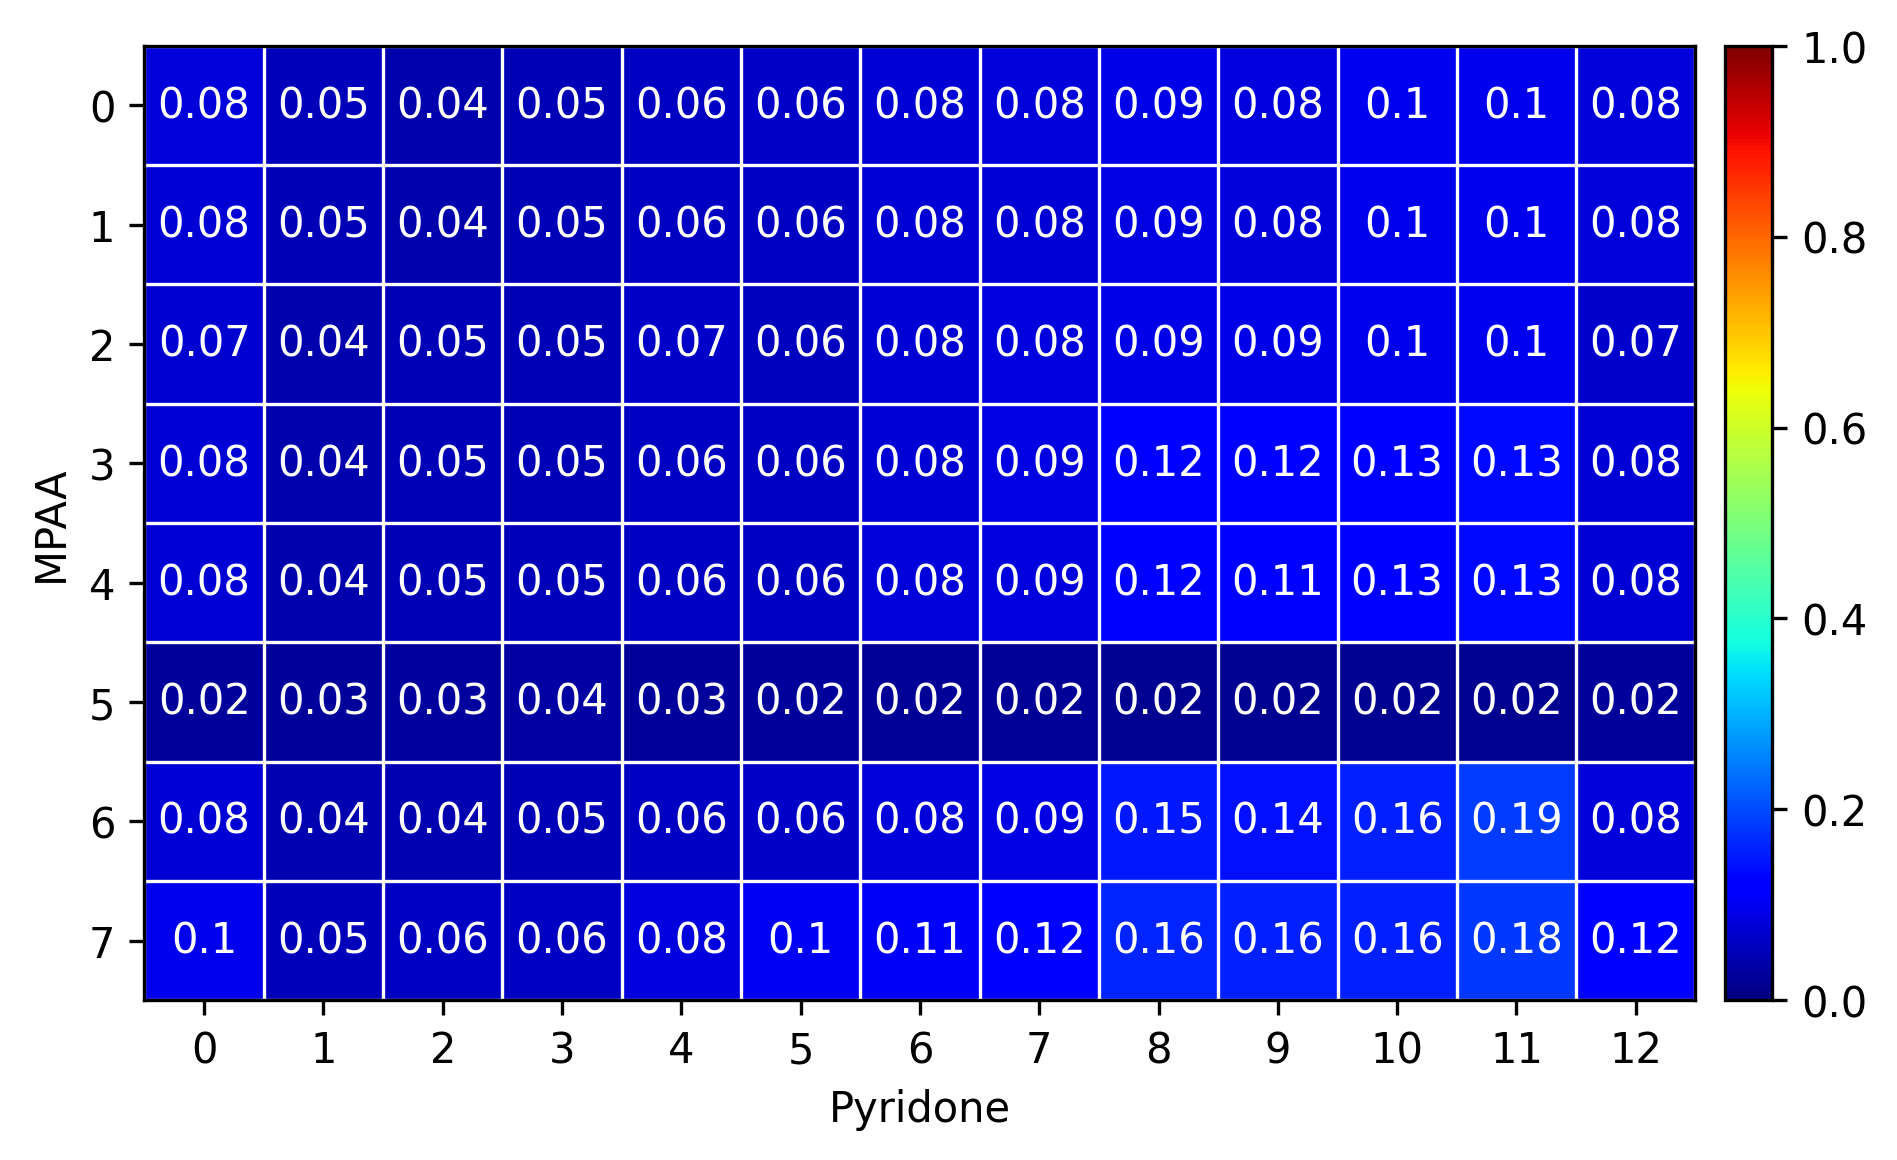

In [18]:
fig, ax = plt.subplots(figsize=(7, 5), dpi=300)

im = ax.imshow(data, vmin=0.0, vmax=1.0, cmap="jet")

ax.set_xticks(np.arange(-0.5, data.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, data.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.8)
ax.tick_params(which="minor", bottom=False, left=False)

ax.set_xlabel("Pyridone")
ax.set_ylabel("MPAA")
ax.set_xticks(np.arange(data.shape[1]))
ax.set_yticks(np.arange(data.shape[0]))
ax.set_xticklabels(df_pivot_.columns)
ax.set_yticklabels(np.arange(data.shape[0]))

for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = round(data[i, j], 2)
        color = "white" if val <= 30 else "black"
        ax.text(
            j, i,
            val,
            ha="center",
            va="center",
            color=color
        )

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)
fig.colorbar(im, cax=cax)

plt.savefig(
    f"{file}_imshow_selectivity.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()